In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
print(os.getpid())
sys.path.append(os.path.abspath("./"))
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

import stepanoff

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

20568
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_      = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_root_ = "../QuCF/simulations/Stepanoff/"
for i in range(100):
    plt.close()

In [ ]:
# -------------------------------------------------------------------
# --- Main parameters ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
def compute_QuCF_parameters_for_initialization(N):
    # --- Initialization for angle = [0, np.pi] ---
    alpha_0 = 0.
    alpha_1 = np.pi * N/(2.*(N - 1))

    n = int(np.log2(N))
    nD = 2 * n

    # --- for QSP: for angle = [0, 2*np.pi] ---
    alpha_0_qsp = 0.
    alpha_1_qsp = (2. * np.pi) * N/(2.*(N - 1))

    # --- Printing ---
    print()
    print("// --- For spatial and time grids ---")
    print("\tNt \t{:d}".format(Nt_))
    print("\tnx \t{:d}".format(n))
    print("\tnxD \t{:d}".format(nD))
    print("// --- For initialization subcircuit ---")
    print("\talpha_init_0 \t{:0.12e}".format(alpha_0))
    print("\talpha_init_1 \t{:0.12e}".format(alpha_1))
    print("// --- For QSP BE sin oracle ---")
    print("\talpha_qsp_0 \t{:0.12e}".format(alpha_0_qsp))
    print("\talpha_qsp_1 \t{:0.12e}".format(alpha_1_qsp))
    return
# -----------------------------------------------------
# --- Parameters for temporal and spatial grids ---
# Total time interval is dt_ * Nt_
# -----------------------------------------------------------------  

flag_norm_max_, rr_init_ = True, None  # normalization to the maximum value
nx_ = 6
# dt_, Nt_ = 0.01, 100   
dt_, Nt_ = 0.1, 10   # total time interval is dt_ * Nt_

# --- other parameters ---
alpha_ = np.sqrt(20.)
kappa_ = 1.
file_qucf_ = "sim"
path_qucf_ = path_qucf_root_ + "/sim_diag_dt{:0.3f}".format(dt_)

# --- spatial grid ---
Nx_ = 1 << nx_
nx_half_ = nx_ - 1
Nx_half_ = 1 << nx_half_
x_ = np.linspace(0., 2.*np.pi, Nx_)

# --- initialization ---
compute_QuCF_parameters_for_initialization(Nx_)
# stepanoff.plot_init(kappa_, x_)

# --- unitary operators ---
init_2d_    = stepanoff.f_init_2d(kappa_, x_, Nx_)
diag_U_M1_  = stepanoff.create_diag_matrix(dt_, Nx_half_, alpha_, "M1", True)
diag_U_M2_  = stepanoff.create_diag_matrix(dt_, Nx_half_, alpha_, "M2", True)


// --- For spatial and time grids ---
	Nt 	10
	nx 	6
	nxD 	12
// --- For initialization subcircuit ---
	alpha_init_0 	0.000000000000e+00
	alpha_init_1 	1.595729601823e+00
// --- For QSP BE sin oracle ---
	alpha_qsp_0 	0.000000000000e+00
	alpha_qsp_1 	3.191459203647e+00


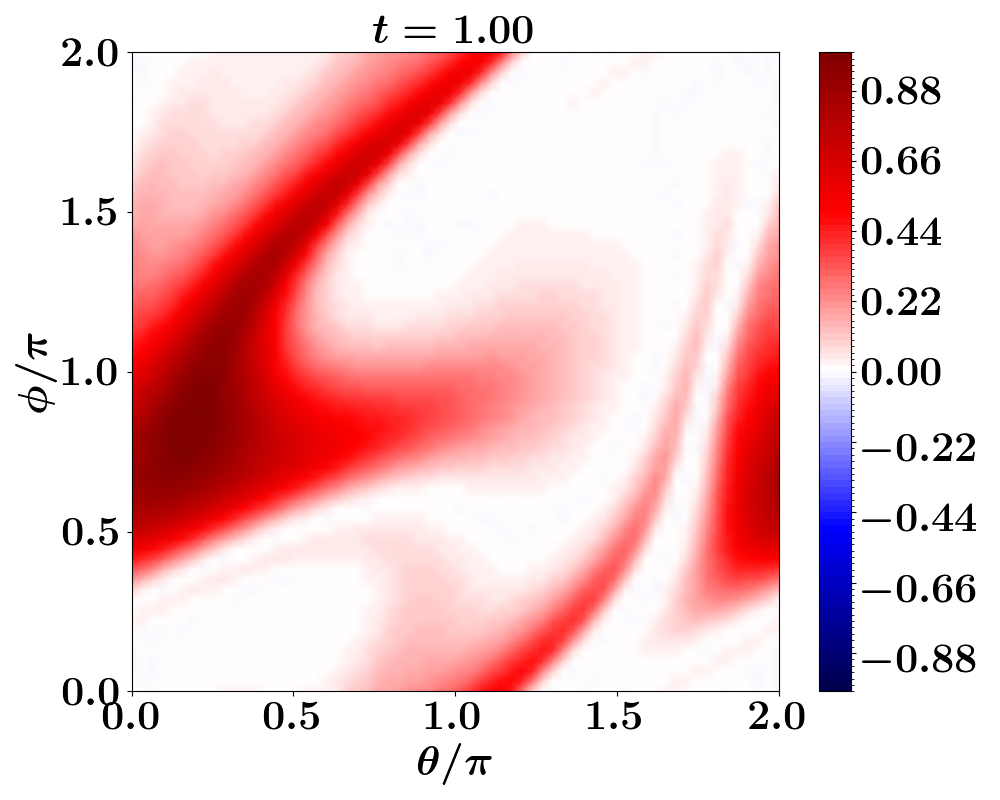

In [5]:
# -------------------------------------------------------------------
# --- Classical simulations in real-Fourier space  ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
y_cl_mod_mix_, y_cl_mix_ = stepanoff.computation_in_real_and_fourier(
    dt_, Nt_, x_,
    diag_U_M1_, diag_U_M2_, init_2d_,
    flag_plot = True,
    flag_norm_max = flag_norm_max_
)

In [6]:
# -------------------------------------------------------------------
# --- Classical simulations in real space  ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
y_cl_dopri_ = stepanoff.get_Dopri_classical_simulations(
    dt_, Nt_, x_,
    alpha_, kappa_,
    path_save = path_save_,
    prefix = "new_", 
    flag_plot = False,
    flag_norm_max = flag_norm_max_
)

--- Looking for the file: new_Stepanoff_data_k1.0_a4.472_n6.hdf5 in the path ./jupyter-notebooks/Stepanoff/results/
--- Loading data ---
Reading the coefficients from:
 ./jupyter-notebooks/Stepanoff/results/new_Stepanoff_data_k1.0_a4.472_n6.hdf5

Take the Dopri simulation at t = 1



Reading the file ../QuCF/simulations/Stepanoff//sim_diag_dt0.100/sim_nx6_t1_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is sim
Simulation has been performed  04-03-2025 14:22:00

A-max: 4.934466870656e-02
success prob: 9.999e-01
N-gates: 266454
max. abs. err (mix  space): 2.899e-10
max. abs. err (real space): 4.841e-01


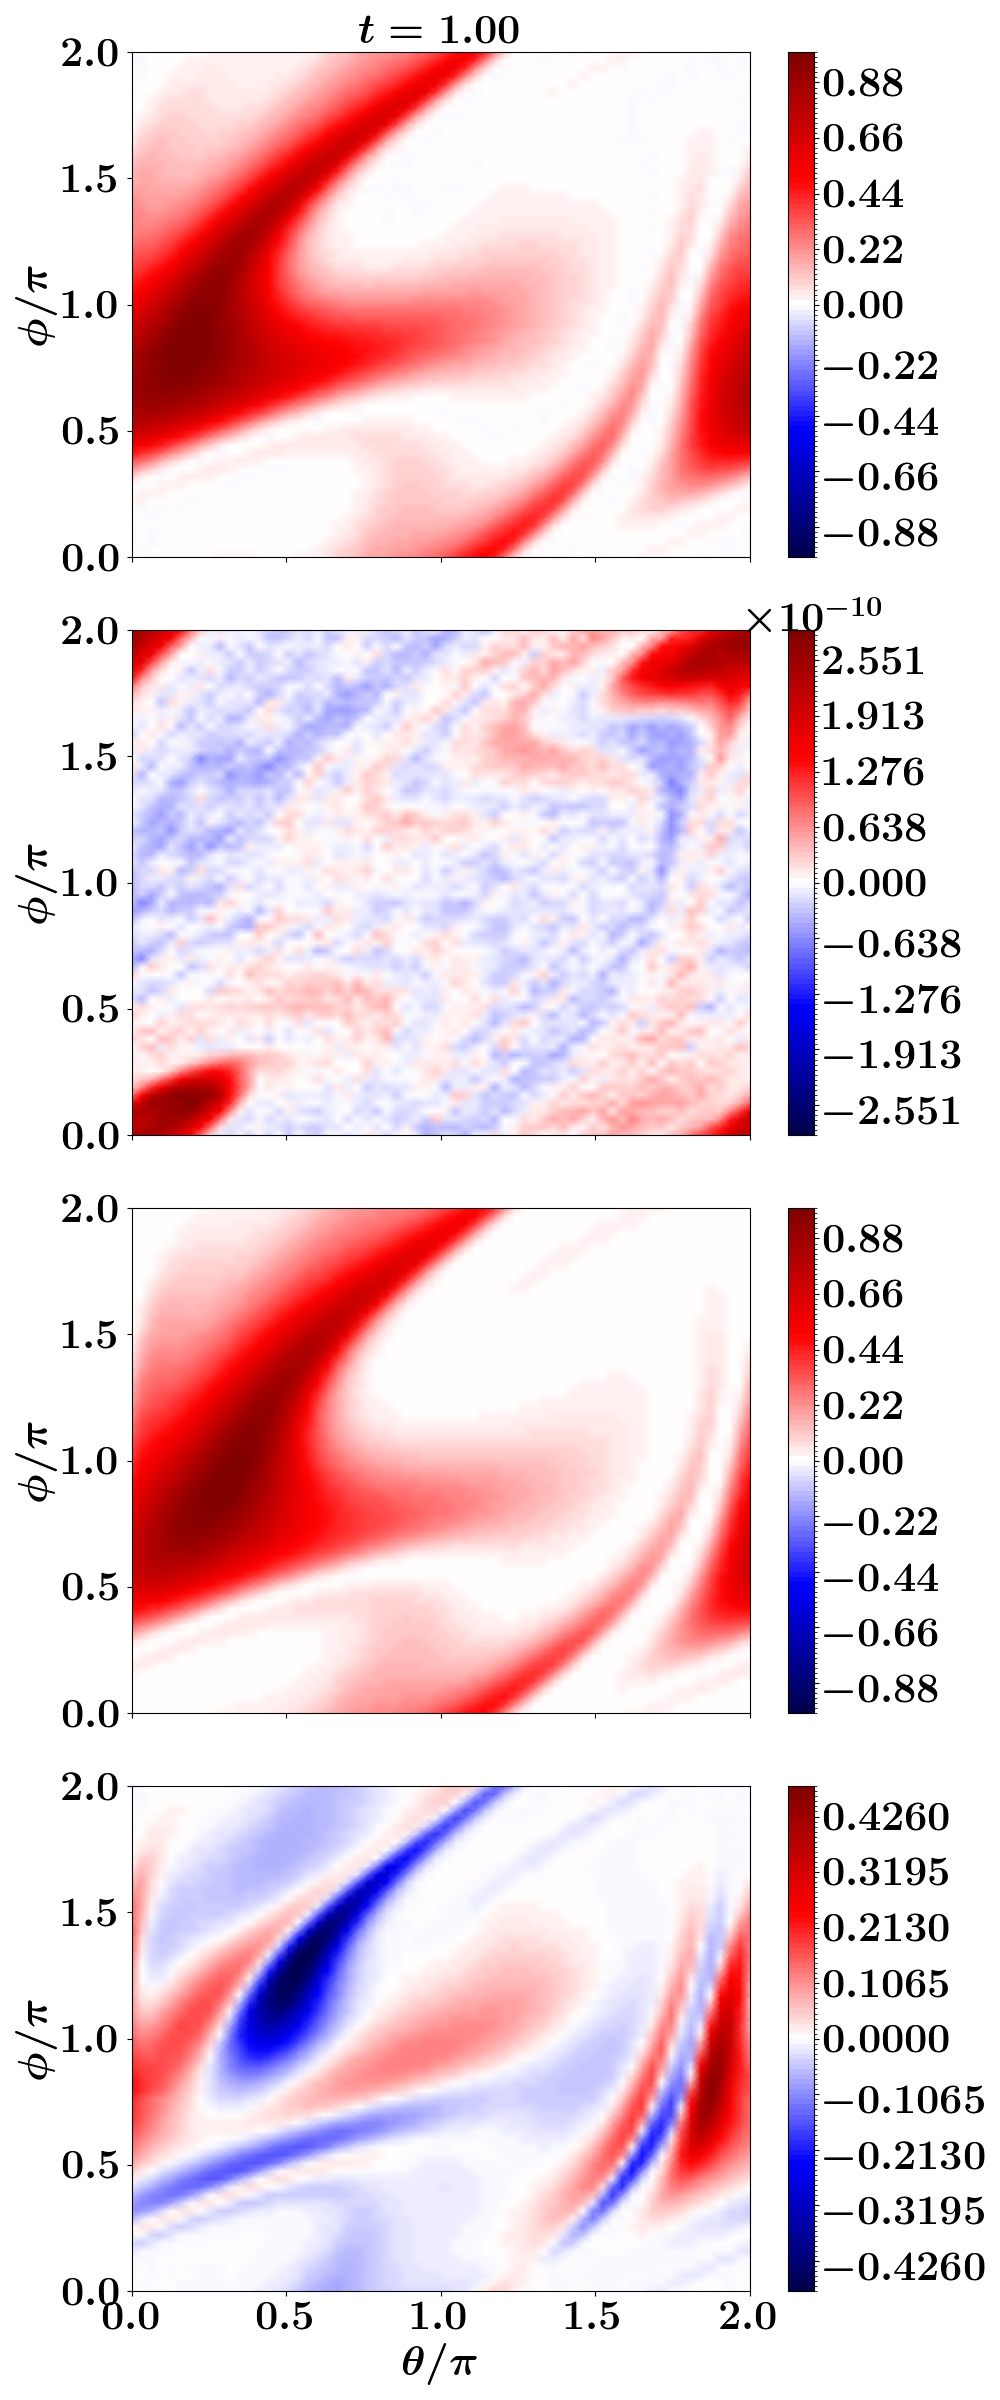

In [ ]:
# -------------------------------------------------------------------
# --- Compare classical and QuCF results ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
def read_qc_data(path_qc, name_file_qc):
    print()  

    # --- Read the _OUTPUT.hdf5 file ---
    om = mse.MeasOracle__()
    om.path_  = path_qc
    om.pname_ = name_file_qc
    om.open()
    
    # --- get the result ---
    Ngates = om.dd_["N-gates"]
    om.set_zero_ancillae_work_states(0)
    qc_state = om.get_var_x({}, "r")

    resc_coef = 1.
    if not flag_norm_max_:
        om.read_qsvt()
        resc_qsvt = om.dd_["init"]["rescaling_factor"]
        Hadamart_norm_factor = 2.**(nx_//2)
        resc_coef = (Hadamart_norm_factor / resc_qsvt)**2
        resc_coef *= 1. / rr_init_
        
    print()
    print("A-max: {:0.12e}".format(np.max(np.abs(qc_state))))
    print("success prob: {:0.3e}".format(  np.sum(np.abs(qc_state)**2)  ))
    print("N-gates: {:d}".format(Ngates))

    qc_state *= resc_coef

    return qc_state
# -------------------------------------------------------------------
def compare_classical_qucf(
        y_cl_mod_mix, y_cl_mix, y_cl_dopri, 
        path_qucf, file_qucf,
        flag_plot
    ):
    # --- QuCF data ---
    psi_qc_1d = read_qc_data(path_qucf, file_qucf)

    psi_qc_1d_real = psi_qc_1d.real
    psi_qc_2d = stepanoff.rearrange_into_2d(psi_qc_1d_real, Nx_)

    # --- Change of coordinates back to the original ---
    y_res_qc = stepanoff.change_coord_to_orig(psi_qc_2d, Nx_)

    if flag_norm_max_:
        y_res_qc /= np.max(np.abs(y_res_qc)) 

    # --- Error ---
    err_mix = y_res_qc - y_cl_mix
    max_abs_err_mix = np.max(np.abs(err_mix))

    err_real = y_res_qc - y_cl_dopri
    max_abs_err_real = np.max(np.abs(err_real))

    print("max. abs. err (mix  space): {:0.3e}".format(max_abs_err_mix))
    print("max. abs. err (real space): {:0.3e}".format(max_abs_err_real))

    # --- Plotting ---
    if flag_plot:
        X, Y = np.meshgrid(x_/np.pi, x_/np.pi)
        fig1, axs = plt.subplots(4, 1, figsize=(10,24))
        stepanoff.plot_2D_subplot(
            axs[0], fig1, X, Y, y_res_qc,  
            str_title="$" + "t={:0.2f}".format(Nt_*dt_) + "$", 
            label_x = '', label_y = "$\phi/\pi$", 
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[1], fig1, X, Y, err_mix,   
            label_x = '', label_y = "$\phi/\pi$",
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[2], fig1, X, Y, y_cl_dopri,  
            label_x = '', label_y = "$\phi/\pi$", 
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[3], fig1, X, Y, err_real,  
            label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
        )
        plt.tight_layout()
    return
# ----------------------------------------------------------------------
file_output = "sim_nx{:d}_t{:d}".format(nx_, int(Nt_*dt_))

compare_classical_qucf(
    y_cl_mod_mix_, y_cl_mix_, y_cl_dopri_, 
    path_qucf_, file_output,
    flag_plot = True
)

In [5]:
# ---------------------------------------------------------------------------
# --- Scaling: the number of gates in QuCF simulations ---
# ---------------------------------------------------------------------------
def scaling_Ng():
    def save_one(x, y, dt_loc, t_loc, str_v):
        str_dt = "dt{:0.3f}".format(dt_loc)
        str_t = "t{:d}".format(int(t_loc))

        x = np.array(x)
        y = np.array(y)

        str_file = "{:s}_{:s}_{:s}".format(str_v, str_t, str_dt)

        mix.save_dat_plot_1d_file(
            path_save_ + "/scaling_{:s}.dat".format(str_file), 
            x, y
        )
        return
    # ------------------------------------------------------------------

    # ----------------------------------------------------------------------
    # --- t = 1 ---
    # ----------------------------------------------------------------------
    t = 1.

    # ---------------------------------------------------------------
    dt = 0.1
    nx_arr = np.array([     6,      7,      8,       9,      10])
    Ng_arr = np.array([266454, 438794, 750534, 1336874, 2470534])
    save_one(nx_arr, Ng_arr, dt, t, "QC_Ng_nx")

    # ---------------------------------------------------------------
    dt = 0.01
    nx_arr = np.array([      6,       7,       8,       9,      10])
    Ng_arr = np.array([1019934, 1462614, 2128494, 3167374, 4919654])
    save_one(nx_arr, Ng_arr, dt, t, "QC_Ng_nx")

    return
# ---------------------------------------------------------------------------
scaling_Ng()

write data to a file: ./jupyter-notebooks/Stepanoff/results//scaling_QC_Ng_nx_t1_dt0.100.dat
write data to a file: ./jupyter-notebooks/Stepanoff/results//scaling_QC_Ng_nx_t1_dt0.010.dat


Reading the file ../QuCF/simulations/Stepanoff/sim_diag/sim_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is sim
Simulation has been performed  04-03-2025 13:56:19
max-abs-err: 1.617e-12
max-diff-abs-err: 1.617e-12


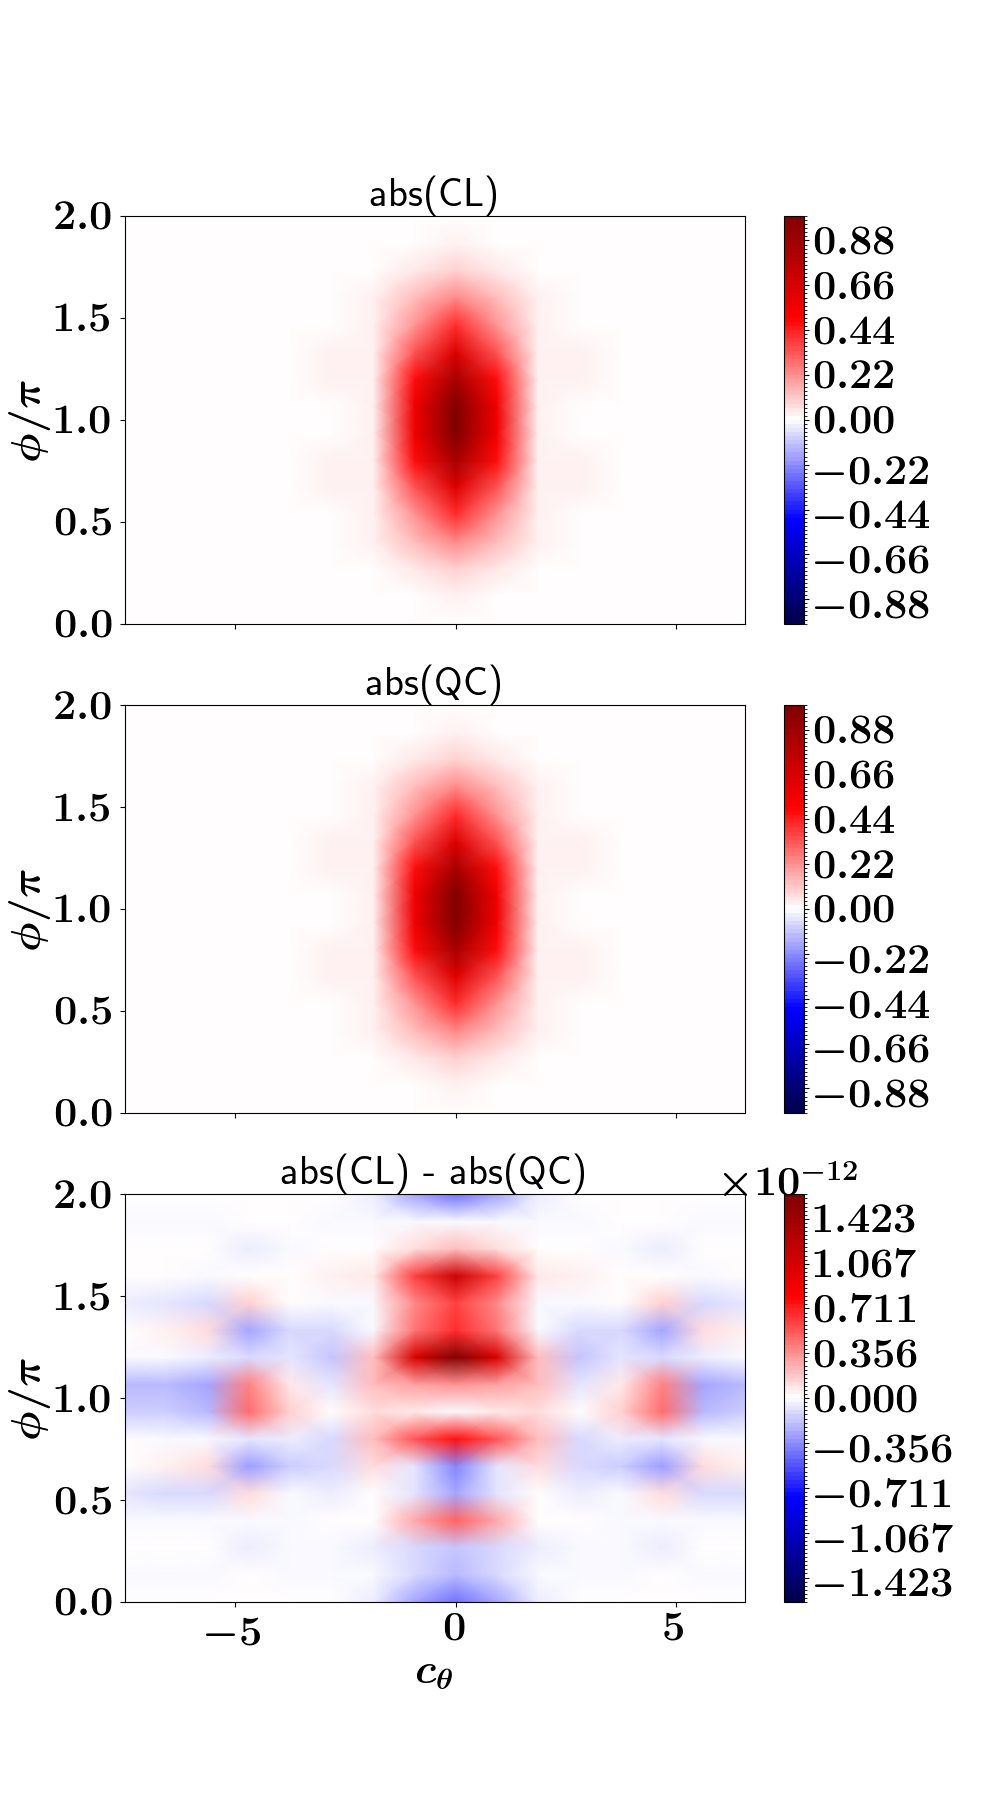

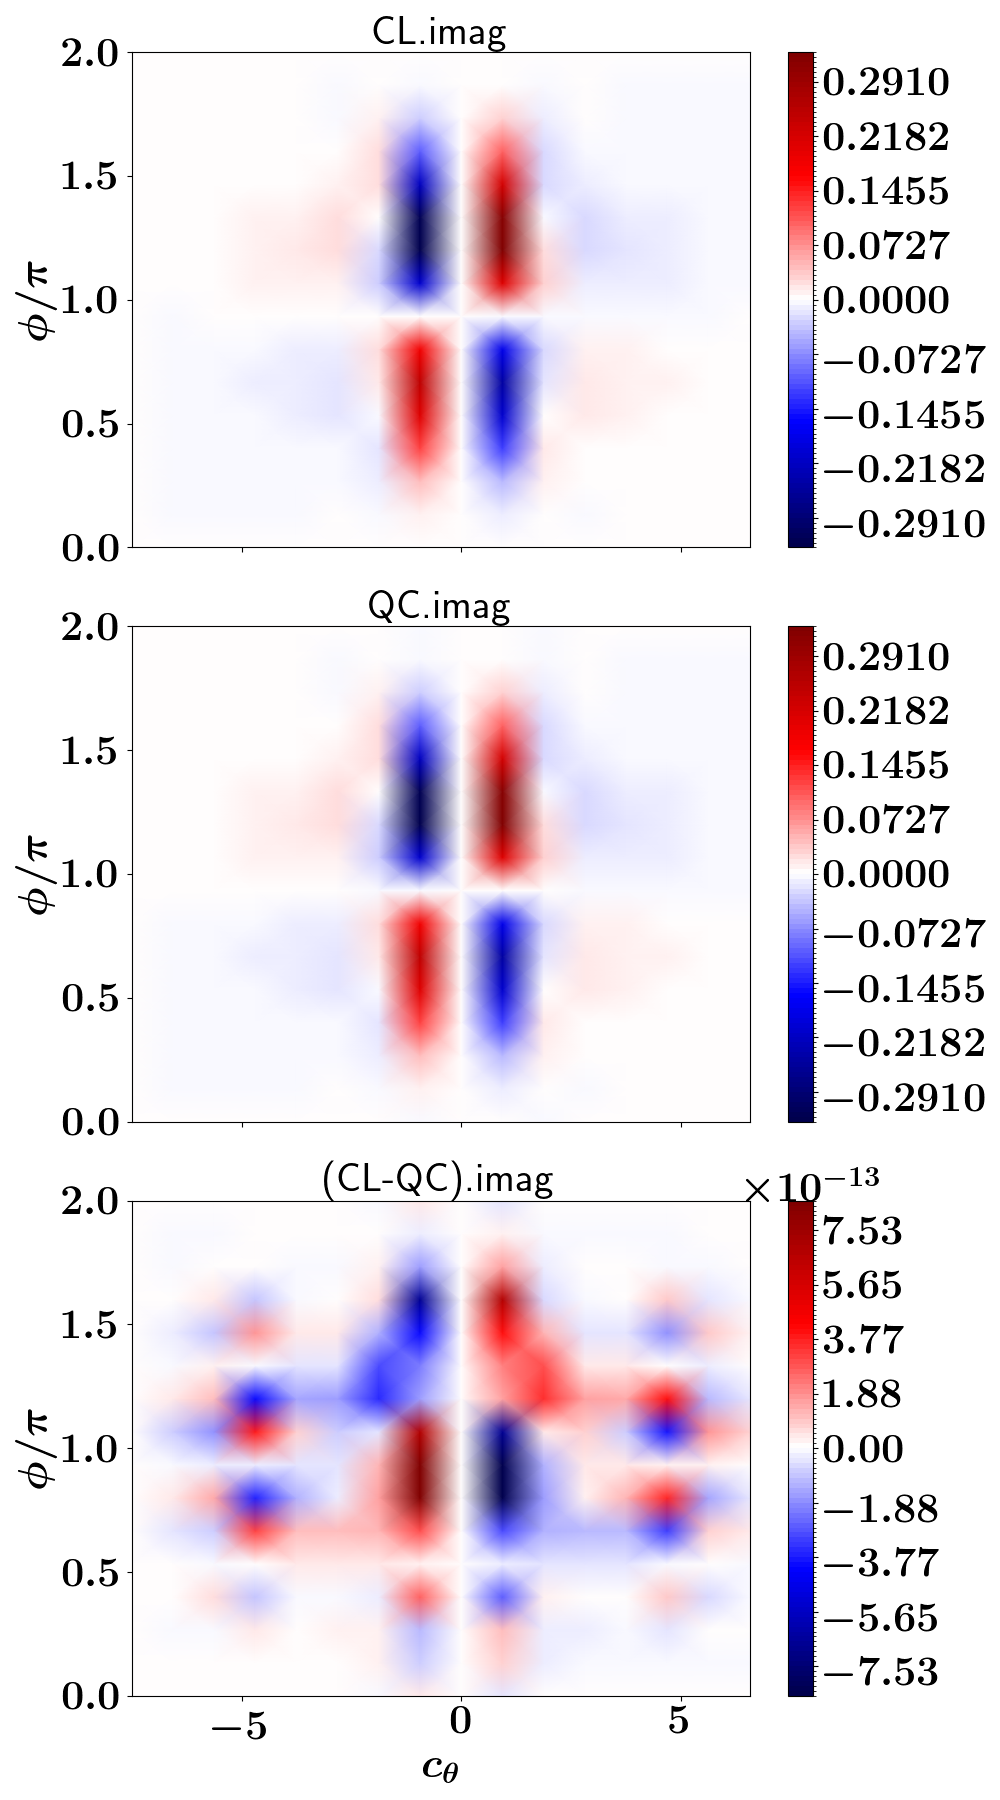

In [ ]:
# ------------------------------------------------------------
# --- Test: initialization ---
# ------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(mse)
mix.reload_module(stepanoff)
def plot_qucf_init_FOURIER(path_qucf, file_qucf, flag_fourier_theta):
    def rearrange_fourier_elements(fft_2d_init):
        fft_signal = np.zeros((Nx, Nx), dtype=complex)
        fft_signal = np.fft.fftshift(fft_2d_init, axes=id_axis)

        max_ampl = np.max(np.abs(fft_signal))
        fft_signal /= max_ampl
        return fft_signal
    # ---------------------------------------------------------
    id_axis = 1 - int(flag_fourier_theta)

    # --- reading QuCF simulations ---
    om = mse.MeasOracle__()
    om.path_  = path_qucf
    om.pname_ = file_qucf
    om.open()

    # --- spatial grid ---
    nx = int(om.constants_["nx"])
    Nx = 1 << nx
    x = np.linspace(0, 2.*np.pi, Nx)

    # --- Fourier grid ---
    coef_ff = 2.*np.pi
    dx = np.diff(x)[0]
    dk = coef_ff / (dx*Nx)
    k_array_pos = np.linspace(              0, coef_ff/(2*dx) - dk, Nx//2) 
    k_array_neg = np.linspace(-coef_ff/(2*dx),                 -dk, Nx//2)
    k_array = np.concatenate((k_array_neg, k_array_pos))

    # -------------------------------------
    # --- QuCF signal ---
    om.set_zero_ancillae_work_states(0)
    f_qucf = om.get_var_x({}, "r")

    # Fourier spectrum is properly arranged by the extra X gate after quantum Fourier
    f_qucf_2D = stepanoff.rearrange_into_2d(f_qucf, Nx)
    max_ampl = np.max(np.abs(f_qucf_2D))
    fft_qucf = f_qucf_2D / max_ampl

    # -------------------------------------
    # --- classical Fourier ---
    f_cl = stepanoff.f_init_2d(kappa_, x, Nx) 
    fft_cl = np.fft.fft(f_cl, axis=id_axis)
    fft_cl = rearrange_fourier_elements(fft_cl)

    # -------------------------------------
    # --- Errors ---
    # QuCF returns complex-conjugate of the classical signal
    err_abs_2D = fft_cl - fft_qucf
    print("max-abs-err: {:0.3e}".format(  np.max(np.abs(err_abs_2D))  ))

    diff_abs_2D = np.abs(fft_cl) - np.abs(fft_qucf)
    print("max-diff-abs-err: {:0.3e}".format(  np.max(np.abs(diff_abs_2D))  ))

    # -------------------------------------
    # --- Plotting ---    
    if flag_fourier_theta:
        X, Y = np.meshgrid(k_array, x/np.pi)
        label_x, label_y = '$c_{\\theta}$', "$\phi/\pi$"
    else:
        X, Y = np.meshgrid(x/np.pi, k_array)
        label_x, label_y = '$\\theta/\pi$', "$c_{\phi}$"

    fig1, axs = plt.subplots(3, 1, figsize=(10,18))
    stepanoff.plot_2D_subplot(axs[0], fig1, X, Y, np.abs(fft_cl.transpose()),     "abs(CL)",    label_x = "", label_y = label_y, flag_x = False)
    stepanoff.plot_2D_subplot(axs[1], fig1, X, Y, np.abs(fft_qucf.transpose()),   "abs(QC)",    label_x = "", label_y = label_y, flag_x = False)
    stepanoff.plot_2D_subplot(axs[2], fig1, X, Y, diff_abs_2D.transpose(), "abs(CL) - abs(QC)", label_x = label_x, label_y = label_y)

    fig1, axs = plt.subplots(3, 1, figsize=(10,18))
    stepanoff.plot_2D_subplot(axs[0], fig1, X, Y, fft_cl.imag.transpose(),     "CL.imag",      label_x = "", label_y = label_y, flag_x = False)
    stepanoff.plot_2D_subplot(axs[1], fig1, X, Y, fft_qucf.imag.transpose(),   "QC.imag",      label_x = "", label_y = label_y, flag_x = False)
    stepanoff.plot_2D_subplot(axs[2], fig1, X, Y, err_abs_2D.imag.transpose(), "(CL-QC).imag", label_x = label_x, label_y = label_y)

    plt.tight_layout()
    return
# -------------------------------------------------------------
plot_qucf_init_FOURIER(path_qucf_, file_qucf_, flag_fourier_theta = True)